In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings("ignore")  # suppress warnings

from sklearn.model_selection import KFold, cross_val_score

In [2]:
# load Data
genetic = pd.read_csv("COREAD_Genetic_features.csv")
drug_ic = pd.read_csv("COREAD_IC.csv")
anova = pd.read_csv("COREAD_ANOVA.csv")

print("Genetic shape:", genetic.shape)
print("Drug IC shape:", drug_ic.shape)
print("ANOVA shape:", anova.shape)

Genetic shape: (3102, 9)
Drug IC shape: (12628, 13)
ANOVA shape: (23652, 22)


In [3]:
# Clean column names
genetic.columns = genetic.columns.str.strip()
drug_ic.columns = drug_ic.columns.str.strip()

print(genetic.head())
print(drug_ic.head())

  Cell Line Name  COSMIC ID        GDSC Desc1       GDSC Desc2 TCGA Desc  \
0          CaR-1     924108  digestive_system  large_intestine    COREAD   
1          CaR-1     924108  digestive_system  large_intestine    COREAD   
2          CaR-1     924108  digestive_system  large_intestine    COREAD   
3          CaR-1     924108  digestive_system  large_intestine    COREAD   
4          CaR-1     924108  digestive_system  large_intestine    COREAD   

  Genetic Feature  IS Mutated Recurrent Gain Loss  \
0      cnaCOREAD1           0                gain   
1      cnaCOREAD2           0                loss   
2      cnaCOREAD3           0                loss   
3      cnaCOREAD4           0                loss   
4      cnaCOREAD5           0                loss   

                                    Genes in Segment  
0                               IGF2,INS,INS-IGF2,TH  
1  AP006621.5,AP2A2,BRSK2,C11orf35,C11orf89,CD151...  
2                                               SBF2  
3   

In [4]:
# Create Genetic Fingerprint Matrix
genetic_pivot = genetic.pivot_table(
    index="Cell Line Name",
    columns="Genetic Feature",
    values="IS Mutated",
    fill_value=0
)

genetic_pivot.reset_index(inplace=True)

print("Genetic fingerprint shape:", genetic_pivot.shape)
print(genetic_pivot.columns[1:])
print(genetic_pivot.head())

Genetic fingerprint shape: (47, 67)
Index(['cnaCOREAD1', 'cnaCOREAD10', 'cnaCOREAD11', 'cnaCOREAD12',
       'cnaCOREAD13', 'cnaCOREAD14', 'cnaCOREAD15', 'cnaCOREAD16',
       'cnaCOREAD17', 'cnaCOREAD18', 'cnaCOREAD19', 'cnaCOREAD2',
       'cnaCOREAD20', 'cnaCOREAD21', 'cnaCOREAD22', 'cnaCOREAD23',
       'cnaCOREAD24', 'cnaCOREAD25', 'cnaCOREAD26', 'cnaCOREAD27',
       'cnaCOREAD28', 'cnaCOREAD29', 'cnaCOREAD3', 'cnaCOREAD30',
       'cnaCOREAD31', 'cnaCOREAD32', 'cnaCOREAD33', 'cnaCOREAD34',
       'cnaCOREAD35', 'cnaCOREAD36', 'cnaCOREAD37', 'cnaCOREAD38',
       'cnaCOREAD39', 'cnaCOREAD4', 'cnaCOREAD40', 'cnaCOREAD41',
       'cnaCOREAD42', 'cnaCOREAD43', 'cnaCOREAD44', 'cnaCOREAD45',
       'cnaCOREAD46', 'cnaCOREAD47', 'cnaCOREAD48', 'cnaCOREAD49',
       'cnaCOREAD5', 'cnaCOREAD50', 'cnaCOREAD51', 'cnaCOREAD52',
       'cnaCOREAD53', 'cnaCOREAD54', 'cnaCOREAD55', 'cnaCOREAD56',
       'cnaCOREAD57', 'cnaCOREAD58', 'cnaCOREAD59', 'cnaCOREAD6',
       'cnaCOREAD60', 'cnaCOREAD

In [5]:
# Convert Drug File to Wide Format
drug_pivot = drug_ic.pivot_table(
    index="Cell Line Name",
    columns="Drug Name",
    values="IC50"
)

drug_pivot.reset_index(inplace=True)

print("Drug matrix shape:", drug_pivot.shape)
print(drug_pivot.columns[1:])
print(drug_pivot.head())

Drug matrix shape: (46, 289)
Index(['123138', '123829', '150412', '5-Fluorouracil', '5-azacytidine',
       '50869', '615590', '630600', '667880', '720427',
       ...
       'WZ4003', 'Wee1 Inhibitor', 'Wnt-C59', 'XAV939', 'YK-4-279', 'ZM447439',
       'Zoledronate', 'alpha-lipoic acid', 'ascorbate (vitamin C)',
       'glutathione'],
      dtype='object', name='Drug Name', length=288)
Drug Name Cell Line Name    123138    123829    150412  5-Fluorouracil  \
0                 C2BBe1  4.339999  1.373616  2.757674        5.537326   
1                 CCK-81  2.165916  1.735914  2.810663        2.536794   
2                  CL-11  4.265552  2.556481  4.243737        6.881386   
3               COLO-205  2.187756  2.453067  3.815416        2.204207   
4           COLO-320-HSR  1.004846  3.278923  3.166207        3.577211   

Drug Name  5-azacytidine     50869    615590    630600    667880  ...  \
0               4.549504  3.750413  4.337287  2.120558 -0.283964  ...   
1               1.

In [6]:
# Merge Genetic + Drug Data
data = pd.merge(genetic_pivot, drug_pivot, on="Cell Line Name")

print("Merged shape:", data.shape)
#print(data.columns)
print(data.head())

Merged shape: (46, 355)
  Cell Line Name  cnaCOREAD1  cnaCOREAD10  cnaCOREAD11  cnaCOREAD12  \
0         C2BBe1         0.0          0.0          0.0          0.0   
1         CCK-81         0.0          0.0          0.0          0.0   
2          CL-11         0.0          0.0          0.0          0.0   
3       COLO-205         0.0          0.0          1.0          0.0   
4   COLO-320-HSR         0.0          0.0          1.0          1.0   

   cnaCOREAD13  cnaCOREAD14  cnaCOREAD15  cnaCOREAD16  cnaCOREAD17  ...  \
0          0.0          0.0          0.0          0.0          0.0  ...   
1          0.0          0.0          0.0          0.0          0.0  ...   
2          0.0          0.0          0.0          0.0          0.0  ...   
3          0.0          0.0          0.0          0.0          0.0  ...   
4          0.0          0.0          0.0          0.0          0.0  ...   

     WZ4003  Wee1 Inhibitor   Wnt-C59    XAV939  YK-4-279  ZM447439  \
0  4.314370        2.730149

In [7]:
import warnings
warnings.filterwarnings("ignore")  # suppress warnings

from sklearn.model_selection import KFold, cross_val_score

gene_columns = genetic_pivot.columns[1:]
X = data[gene_columns]

drug_names = drug_pivot.columns[1:]

models = {}
results = []

print("Training + Evaluating models for each drug...")

for drug in drug_names:

    y = data[drug].dropna()
    X_filtered = X.loc[y.index]

    # Skip very small datasets
    if len(X_filtered) < 5:
        print(f"Skipping {drug} (too few samples: {len(X_filtered)})")
        continue

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y, test_size=0.2, random_state=42
    )

    # Dynamic KFold
    n_samples = len(X_train)
    n_splits = min(5, n_samples)

    if n_splits < 2:
        print(f"Skipping {drug} (not enough for CV)")
        continue

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    #  FIX: Safe KNN neighbors for CV
    knn_neighbors = max(1, min(5, n_samples - 1))

    model_dict = {
        "Linear": LinearRegression(),
        "GLM": SGDRegressor(max_iter=1000),
        "SVM": SVR(kernel='rbf'),
        "KNN": KNeighborsRegressor(n_neighbors=knn_neighbors),  # FIXED
        "DecisionTree": DecisionTreeRegressor(random_state=42),
        "MLP": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.1, max_iter=5000),
        "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
        "GradientBoosting": GradientBoostingRegressor(random_state=42),
        "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
    }

    models[drug] = {}

    for model_name, model in model_dict.items():

        #  SAFE CV (no crash)
        cv_mse = -cross_val_score(
            model, X_train, y_train,
            cv=kf,
            scoring='neg_mean_squared_error',
            error_score=np.nan   # IMPORTANT
        ).mean()

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)

        models[drug][model_name] = model

        results.append([
            drug, model_name,
            mse,
            cv_mse
        ])

    print("Model trained:", drug)

print("Total drugs:", len(models))



Training + Evaluating models for each drug...
Model trained: 123138
Model trained: 123829
Model trained: 150412
Model trained: 5-Fluorouracil
Model trained: 5-azacytidine
Model trained: 50869
Model trained: 615590
Model trained: 630600
Model trained: 667880
Model trained: 720427
Model trained: 729189
Model trained: 741909
Model trained: 743380
Model trained: 765771
Model trained: 776928
Model trained: A-366
Model trained: ABT737
Model trained: AGI-5198
Model trained: AGI-6780
Model trained: AGK2
Model trained: AMG-319
Model trained: AT13148
Model trained: AZ6102
Model trained: AZ960
Model trained: AZD1208
Model trained: AZD1332
Model trained: AZD2014
Model trained: AZD3759
Model trained: AZD4547
Model trained: AZD5153
Model trained: AZD5363
Model trained: AZD5438
Model trained: AZD5582
Model trained: AZD5991
Model trained: AZD6482
Model trained: AZD6738
Model trained: AZD7762
Model trained: AZD8055
Model trained: AZD8186
Model trained: Acetalax
Model trained: Afatinib
Model trained: Af

In [8]:
#results_df = pd.DataFrame(
 #   results,
  #  columns=["Drug", "Model", "MAE", "MSE"]
#)
results_df = pd.DataFrame(
    results,
    columns=["Drug", "Model", "MSE", "CV_MSE"]
)
# Pivot table (matrix form)
#mae_matrix = results_df.pivot(index="Model", columns="Drug", values="MAE")
mse_matrix = results_df.pivot(index="Model", columns="Drug", values="MSE")



# CV MSE Matrix
cv_mse_matrix = results_df.pivot(
    index="Model",
    columns="Drug",
    values="CV_MSE"
)



print("\n==============================")
print("CROSS-VALIDATION MSE MATRIX")
print("==============================")
print(cv_mse_matrix)


print("\n==============================")
print("\nMSE Matrix:")
print("==============================")
print(mse_matrix)



CROSS-VALIDATION MSE MATRIX
Drug                123138    123829    150412  5-Fluorouracil  5-azacytidine  \
Model                                                                           
DecisionTree      1.272338  2.887203  2.267882        5.043163       4.748565   
ElasticNet        0.777874  1.967055  1.118336        2.626693       2.547725   
GLM               0.911695  2.148244  1.409457        3.203044       2.809677   
GradientBoosting  1.003822  2.219684  1.968115        4.018595       2.805757   
KNN               0.644781  2.929898  1.242717        3.166758       2.467022   
Lasso             0.677890  1.827124  0.981816        3.018977       2.686309   
Linear            2.312615  6.269562  7.045598        9.194326       7.776583   
MLP               1.205740  3.097319  2.131722        5.309848       3.543836   
RandomForest      0.772816  2.092830  1.477839        3.227756       2.628416   
Ridge             0.766403  2.495258  2.218932        2.662452       2.735716   

In [9]:
# Find best model per drug (based on MAE)
##best_model_per_drug = results_df.loc[
 #   results_df.groupby("Drug")["MAE"].idxmin()
#]
best_model_per_drug = results_df.loc[
    results_df.groupby("Drug")["CV_MSE"].idxmin()
]
# Create mapping
best_model_map = {}

for _, row in best_model_per_drug.iterrows():
    best_model_map[row["Drug"]] = row["Model"]

In [10]:
# Existing patient
existing_patient = X.iloc[[4]]

results = []

for drug in models:

    # Get best model name for this drug
    best_model_name = best_model_map[drug]

    # Get that model
    model = models[drug][best_model_name]

    # Predict IC50
    pred = model.predict(existing_patient)[0]

    # Store result
    results.append([drug, best_model_name, pred])

# Create DataFrame
df = pd.DataFrame(results, columns=["Drug", "Best_Model", "Predicted_IC50"])

# Sort → lowest IC50 = best
df = df.sort_values("Predicted_IC50")

print("\n==============================")
print("TOP 10 DRUGS FOR EXISTING PATIENT")
print("==============================")
print(df.head(10))


TOP 10 DRUGS FOR EXISTING PATIENT
                     Drug  Best_Model  Predicted_IC50
84              Daporinad      Linear       -7.152781
219            Romidepsin         SVM       -4.583084
61             Bortezomib         KNN       -4.182799
273           Vinorelbine         SVM       -3.230138
271           Vinblastine         SVM       -2.902307
82           Dactinomycin  ElasticNet       -2.808547
235  Sepantronium bromide       Lasso       -2.521650
229                 SN-38       Lasso       -2.393010
73           Camptothecin         KNN       -2.260231
255            Trametinib         SVM       -2.165413


In [11]:

new_patients = pd.DataFrame([
    np.random.randint(0, 2, 66),  # P1 - random
    np.random.randint(0, 2, 66),  # P2 - random
    np.random.randint(0, 2, 66),  # P3 - random
    np.random.randint(0, 2, 66),  # P4 - random
    np.random.randint(0, 2, 66),
    [1]*66,                       
    [0]*66
], columns=gene_columns)

# Add Patient IDs
new_patients["Patient_ID"] = ["P1", "P2", "P3", "P4", "P5","P6","P7"]

In [12]:
for i in range(len(new_patients)):

    patient_id = new_patients.iloc[i]["Patient_ID"]
    
    # Drop Patient_ID column before prediction
    patient_data = new_patients.drop("Patient_ID", axis=1).iloc[[i]]

    results = []

    for drug in models:

        best_model_name = best_model_map[drug]
        model = models[drug][best_model_name]

        pred = model.predict(patient_data)[0]

        results.append([drug, best_model_name, pred])

    df = pd.DataFrame(results, columns=["Drug", "Best_Model", "Predicted_IC50"])

    df = df.sort_values("Predicted_IC50")

    print("\n==============================")
    print("TOP 5 DRUGS FOR", patient_id)
    print("==============================")
    print(df.head(5))


TOP 5 DRUGS FOR P1
                     Drug Best_Model  Predicted_IC50
84              Daporinad     Linear       -5.295378
235  Sepantronium bromide      Lasso       -4.857901
219            Romidepsin        SVM       -4.683806
61             Bortezomib        KNN       -4.141019
229                 SN-38      Lasso       -3.338455

TOP 5 DRUGS FOR P2
                     Drug Best_Model  Predicted_IC50
219            Romidepsin        SVM       -4.681774
229                 SN-38      Lasso       -4.666567
61             Bortezomib        KNN       -4.442566
235  Sepantronium bromide      Lasso       -4.230070
84              Daporinad     Linear       -3.306310

TOP 5 DRUGS FOR P3
            Drug Best_Model  Predicted_IC50
84     Daporinad     Linear       -5.086300
219   Romidepsin        SVM       -4.678934
61    Bortezomib        KNN       -3.815709
273  Vinorelbine        SVM       -2.985969
271  Vinblastine        SVM       -2.735286

TOP 5 DRUGS FOR P4
            Drug Bes

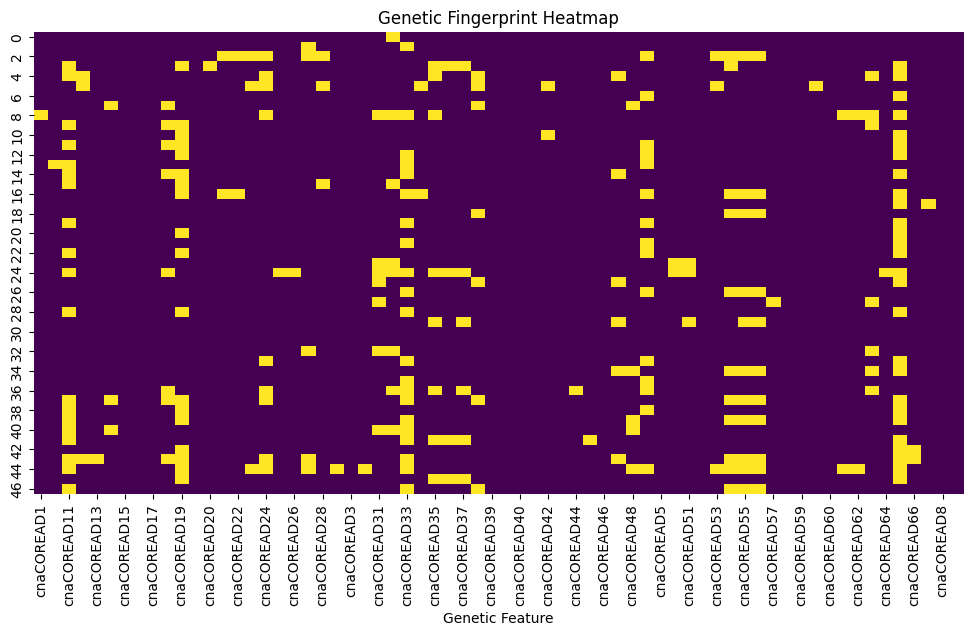

In [13]:
# Genetic Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(genetic_pivot.iloc[:50, 1:], cmap="viridis", cbar=False)
plt.title("Genetic Fingerprint Heatmap")
plt.show()

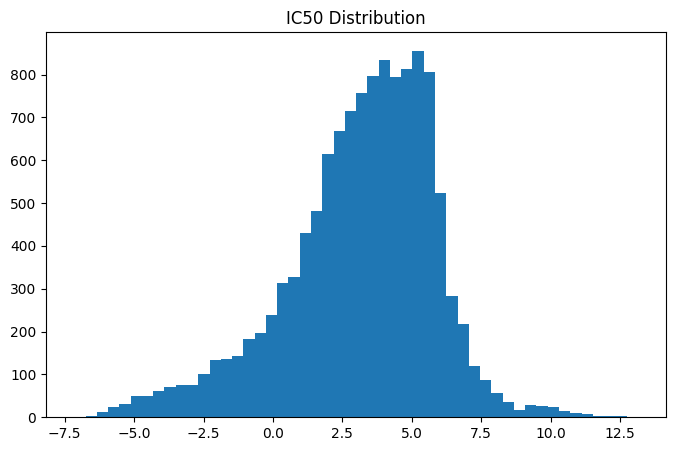

In [14]:
# IC50 distribution
plt.figure(figsize=(8,5))
ic50_values = drug_pivot.iloc[:,1:].values.flatten()
ic50_values = ic50_values[~np.isnan(ic50_values)]
plt.hist(ic50_values, bins=50)
plt.title("IC50 Distribution")
plt.show()


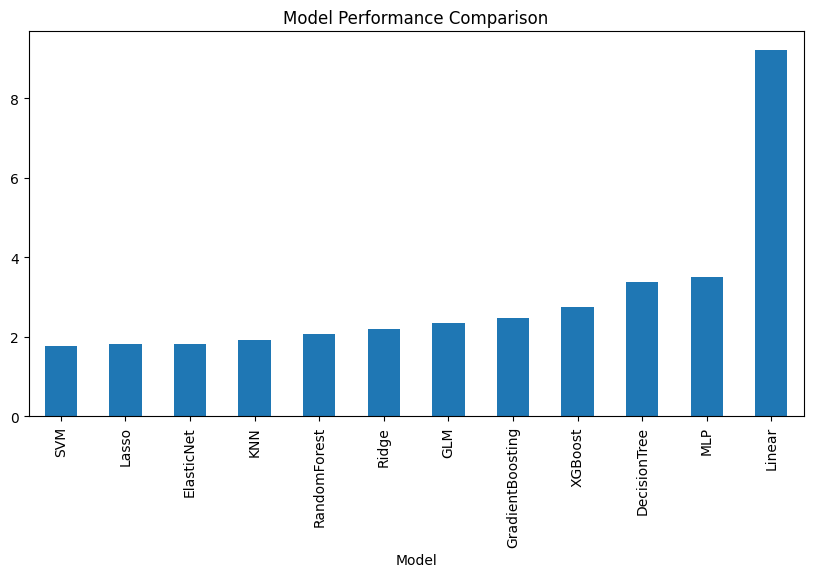

In [15]:
# Model comparison
plt.figure(figsize=(10,5))
model_perf = results_df.groupby("Model")["CV_MSE"].mean().sort_values()
model_perf.plot(kind='bar')
plt.title("Model Performance Comparison")
plt.show()


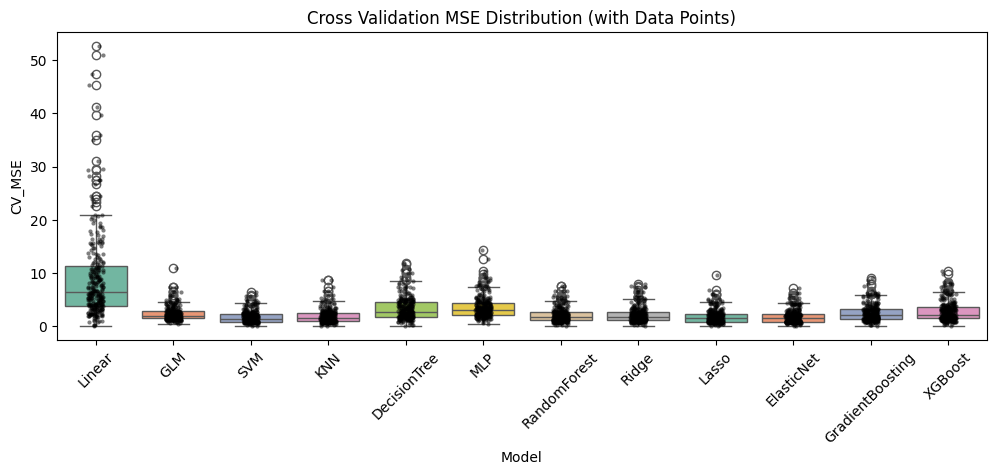

In [16]:
plt.figure(figsize=(12, 4))

palette = sns.color_palette("Set2", n_colors=results_df["Model"].nunique())

sns.boxplot(
    x="Model",
    y="CV_MSE",
    data=results_df,
    palette=palette
)

sns.stripplot(
    x="Model",
    y="CV_MSE",
    data=results_df,
    color='black',
    size=3,
    alpha=0.5
)

plt.xticks(rotation=45)
plt.title("Cross Validation MSE Distribution (with Data Points)")
plt.show()

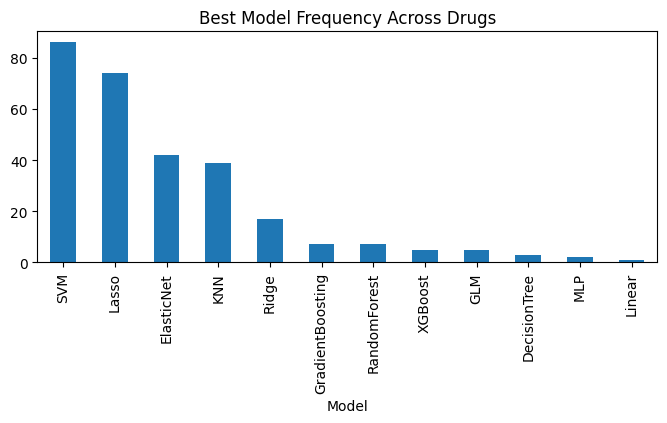

In [17]:
# Best model frequency
plt.figure(figsize=(8, 3))
best_model_per_drug["Model"].value_counts().plot(kind='bar')
plt.title("Best Model Frequency Across Drugs")
plt.show()

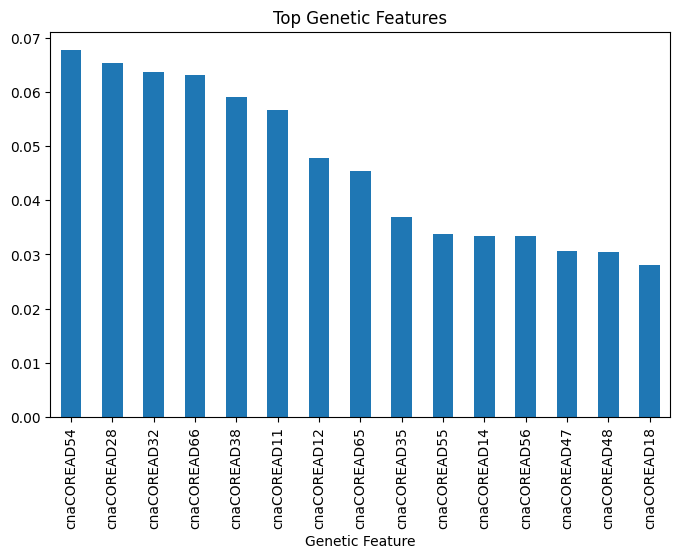

In [18]:
# Feature importance
model = RandomForestRegressor()
model.fit(X, data[drug_names[0]].fillna(data[drug_names[0]].mean()))

importance = pd.Series(model.feature_importances_, index=gene_columns)
importance = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')
plt.title("Top Genetic Features")
plt.show()